In [1]:
import numpy as np
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import load_model

from sklearn.metrics import confusion_matrix

from matplotlib import pyplot as plt

import pickle

tf.config.set_visible_devices([], "GPU")

In [2]:

def assess_model(modelpath, qcsource, qctarget):

    model = load_model(modelpath)


    tX = np.array(pickle.load(open(qcsource, "rb")))
    tX = np.array(tX).reshape(-1,100,2*100,1)
    ty = np.array(pickle.load(open(qctarget, "rb")))

    print(tX.shape, ty.shape)

    predicted = np.argmax(model.predict(tX),axis=1)+1

    conf = confusion_matrix(ty,predicted)

    conf_ = conf/conf.sum(axis=1)[:,None]

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        conf_,
        annot=True,
        fmt='.2f',
        cmap='Greens',
        xticklabels=['Control','Mecillinam','Nalidixate'],
        yticklabels=['Control','Mecillinam','Nalidixate'],
        cbar=False,
        annot_kws={"size": 14}  # Increase annotation font size
    )
    plt.xlabel('Predicted', fontsize=13)
    plt.ylabel('Real', fontsize=15)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title('Accuracy {:.1f}%'.format(100*np.trace(conf)/np.sum(conf)), fontsize=16)
    plt.show()

    return conf

# NO AUGMENTATION

(414, 100, 200, 1) (414,)
13/13 [==============================] - 1s 41ms/step


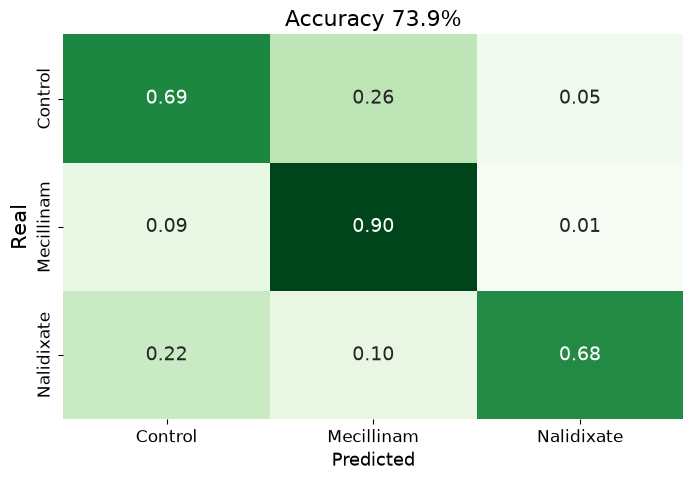

In [3]:
no_aug = assess_model("MODEL_NO_AUG/weights_BEST_0005LR_20split_32batch.h5", "cellstrain.p", "labelstrain.p")

# LR and UP augmentation

(414, 100, 200, 1) (414,)
13/13 [==============================] - 0s 25ms/step


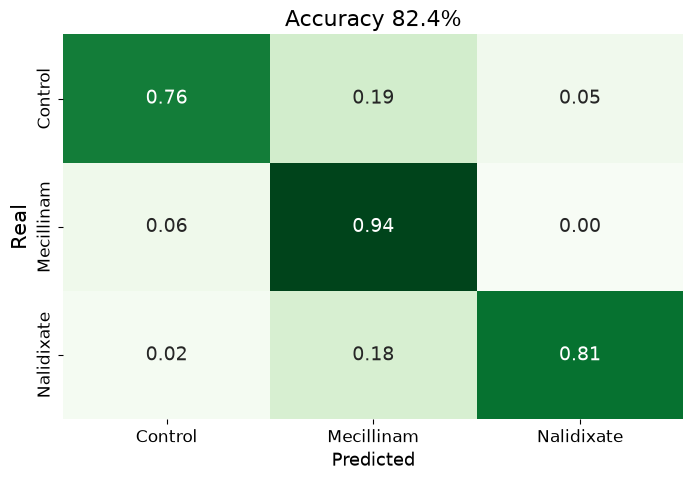

In [4]:
no_aug = assess_model("MODEL_LRUD/weights_BEST_0005LR_20split_32batch.h5", "cellstrain.p", "labelstrain.p")

# LR and UP augmentation plus rotations every 90 degrees

(414, 100, 200, 1) (414,)
13/13 [==============================] - 0s 20ms/step


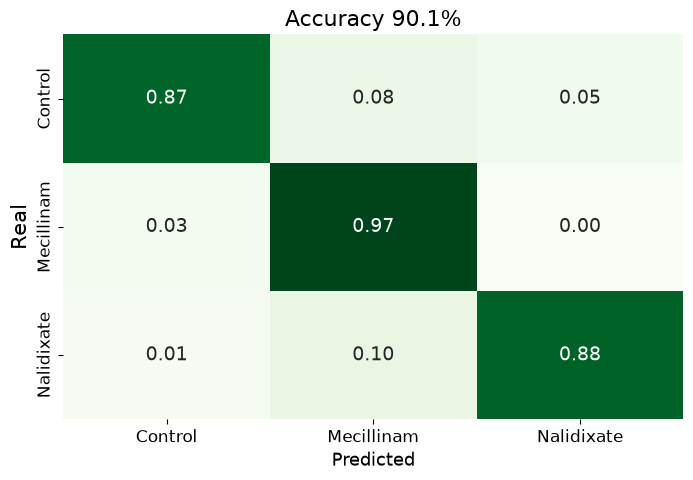

In [5]:
no_aug = assess_model("MODEL_LRUD_90/weights_BEST_0005LR_20split_32batch.h5", "cellstrain.p", "labelstrain.p")

# LR and UP augmentation plus rotations every 45 degrees

(414, 100, 200, 1) (414,)
13/13 [==============================] - 0s 19ms/step


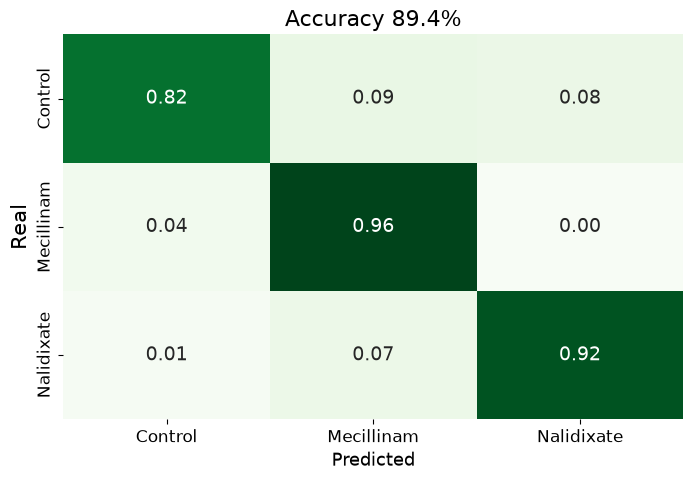

In [6]:
no_aug = assess_model("MODEL_LRUD_45/weights_BEST_0005LR_20split_32batch.h5", "cellstrain.p", "labelstrain.p")

# LR and UP augmentation plus rotations every 15 degrees

(414, 100, 200, 1) (414,)
13/13 [==============================] - 0s 20ms/step


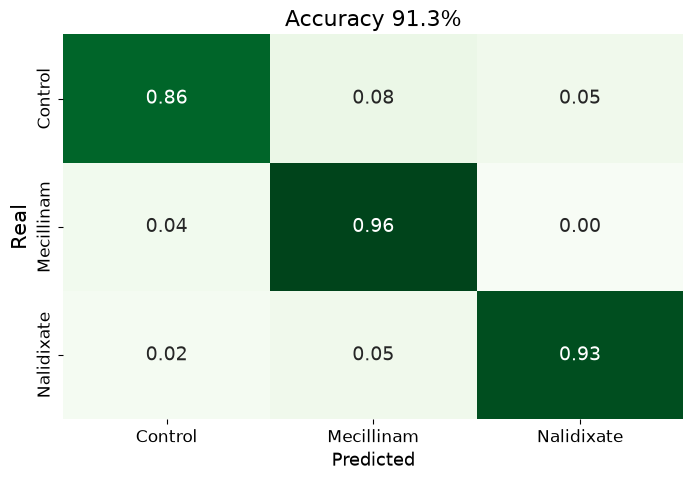

In [7]:
no_aug = assess_model("MODEL_LRUD_15/weights_BEST_0005LR_20split_32batch.h5", "cellstrain.p", "labelstrain.p")